In [1]:
import pandas as pd
import numpy as np
# Read the total CKD visit data
df_total_ckd_visit = pd.read_csv("../data/total_ckd_visit.csv", index_col=0)

# Read the CKD patient data from 2012 to 2023
df_ckd_patient = pd.read_csv("../data/ckd_patient_2012_2023.csv", index_col=0)


In [2]:
df_ckd_patient

,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
other,5938,6253,8102,10337,16755,16052,18038,20695,22113,46823,54095,59810
stage 2,66,79,113,198,528,997,2144,3451,4617,2435,2991,3625
stage 3,598,774,974,832,1576,6057,8940,11678,13610,6854,8390,9833
stage 4,542,683,730,629,1285,2040,2820,3309,3425,2157,7289,2414
stage 5,4782,5040,5301,4511,6694,7052,6879,6972,7122,6917,7565,8178


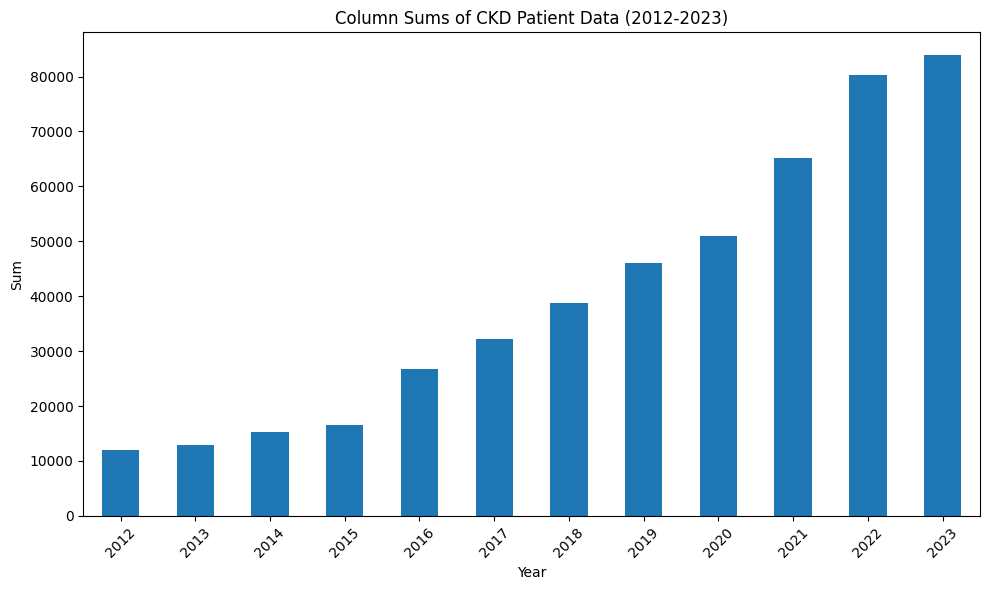

In [3]:
col_sums = df_ckd_patient.sum(axis=0)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
col_sums.plot(kind='bar')
plt.title('Column Sums of CKD Patient Data (2012-2023)')
plt.xlabel('Year')
plt.ylabel('Sum')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [4]:
import pandas as pd

# 创建数据
years = [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
values = [3.82, 3.84, 3.87, 3.90, 3.93, 3.97, 3.99, 4.03, 4.04, 3.99, 4.07, 4.15]

sg_resident_popu = pd.DataFrame({
    'year': years,
    'population': values
})

# 保存到 ../data 文件夹，文件名为 sg_resident_popu.csv
sg_resident_popu.to_csv("../data/sg_resident_popu.csv", index=False)

sg_resident_popu

,year,population
0,2012,3.82
1,2013,3.84
2,2014,3.87
3,2015,3.90
4,2016,3.93
5,2017,3.97
6,2018,3.99
7,2019,4.03
8,2020,4.04
9,2021,3.99


In [5]:
# 计算每年每百万人口的CKD患者总数
million = 1_000_000
ckd_per_million = col_sums.values / (sg_resident_popu["population"].values * million)
ckd_per_million_series = pd.Series(ckd_per_million, index=col_sums.index)
print("每年每百万人口的CKD患者总数：")
print(ckd_per_million_series)


每年每百万人口的CKD患者总数：
2012    0.003122
2013    0.003341
2014    0.003933
2015    0.004233
2016    0.006829
2017    0.008110
2018    0.009730
2019    0.011440
2020    0.012596
2021    0.016337
2022    0.019737
2023    0.020207
dtype: float64


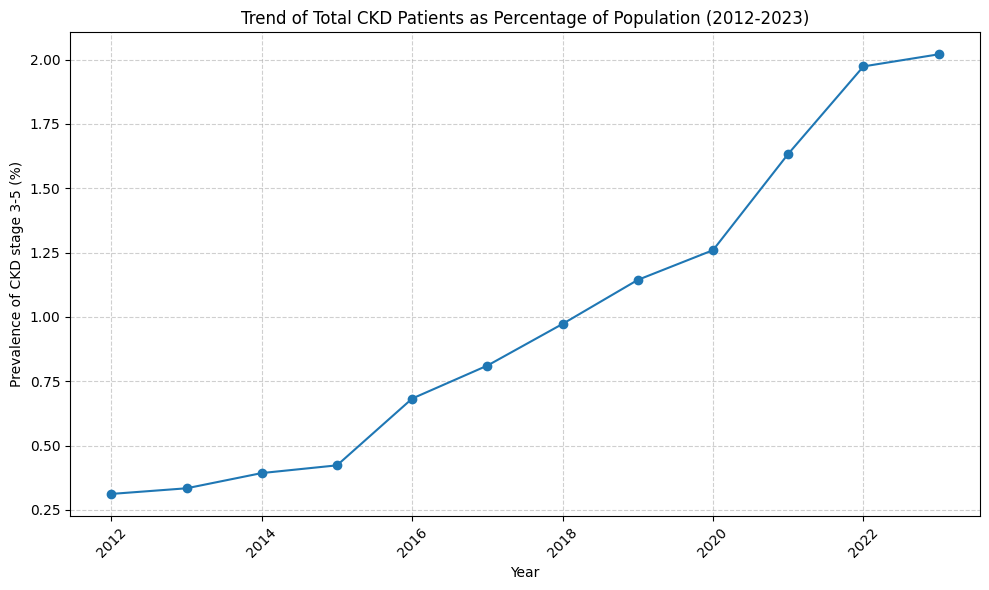

In [8]:
plt.figure(figsize=(10,6))

ckd_percentage_series = ckd_per_million_series  * 100
ckd_percentage_series.plot(marker='o', linestyle='-')
plt.title('Trend of Total CKD Patients as Percentage of Population (2012-2023)')
plt.xlabel('Year')
plt.ylabel('Prevalence of CKD stage 3-5 (%)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [12]:
df_total_ckd_visit

,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
other,65784,119933,100863,53773,106000,103578,114481,129762,138357,239249,274848,304000
stage 2,70,148,183,256,1035,2142,5183,9130,13572,6139,7260,8342
stage 3,654,1449,1510,977,2326,15286,23154,32370,40697,17106,19819,22693
stage 4,607,1352,1220,786,2250,4219,6805,9180,10009,5681,5653,5674
stage 5,9628,17509,15522,8612,16724,17096,16634,17237,17636,20707,22837,25080


In [9]:

total_ckd_visit_array = df_total_ckd_visit.values
ckd_patient_array = df_ckd_patient.values
# Avoid division by zero
with np.errstate(divide='ignore', invalid='ignore'):
    visit_per_patient = np.where(ckd_patient_array != 0, total_ckd_visit_array / ckd_patient_array, np.nan)
print("Result of visit_per_patient calculation:")
print(visit_per_patient)



Result of visit_per_patient calculation:
[[11.0784776  19.18007356 12.44914836  5.20199284  6.32646971  6.45265387
   6.34665706  6.2702102   6.25681726  5.10964697  5.08083926  5.08276208]
 [ 1.06060606  1.87341772  1.61946903  1.29292929  1.96022727  2.14844534
   2.41744403  2.64560997  2.93957115  2.5211499   2.42728185  2.30124138]
 [ 1.09364548  1.87209302  1.55030801  1.17427885  1.47588832  2.5236916
   2.58993289  2.77187875  2.99022777  2.49576889  2.36221692  2.30784094]
 [ 1.1199262   1.9795022   1.67123288  1.24960254  1.75097276  2.06813725
   2.41312057  2.77425204  2.92233577  2.63375058  0.7755522   2.35045568]
 [ 2.01338352  3.47400794  2.92812677  1.90911106  2.49835674  2.4242768
   2.41808402  2.47231784  2.47627071  2.99363886  3.01877065  3.06676449]]


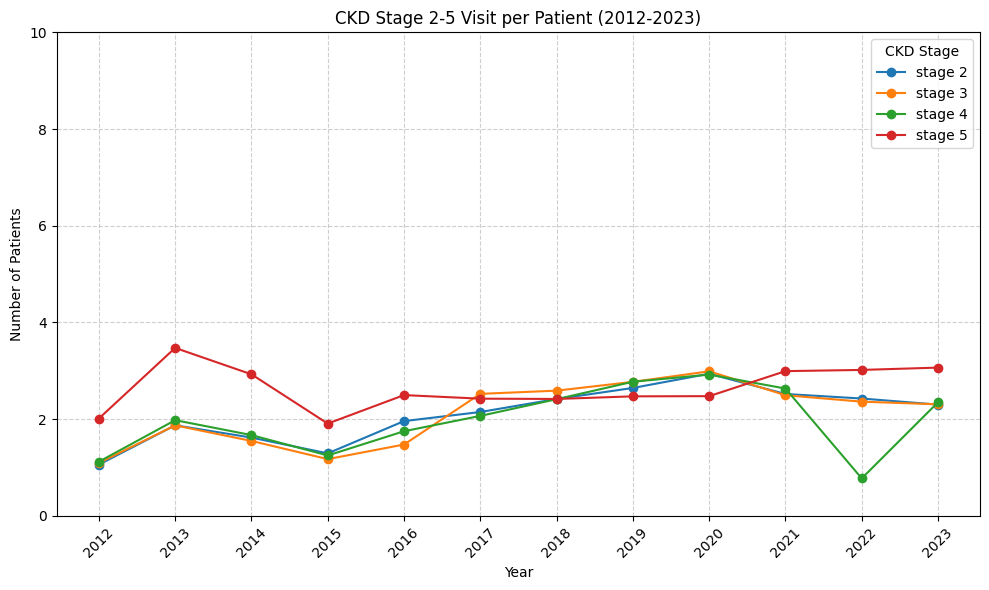

In [13]:
import matplotlib.pyplot as plt

# 取最后4行（假设分别对应stage 2, 3, 4, 5）
stages = ['stage 2', 'stage 3', 'stage 4', 'stage 5']
years = np.arange(2012, 2024)
last4_ckd = visit_per_patient[-4:]

plt.figure(figsize=(10,6))
for i, stage in enumerate(stages):
    plt.plot(years, last4_ckd[i], marker='o', label=stage)

plt.ylim(0, 10)
plt.title('CKD Stage 2-5 Visit per Patient (2012-2023)')
plt.xlabel('Year')
plt.ylabel('Number of Patients')
plt.legend(title='CKD Stage')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(years, rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
ckd_patient_array

In [ ]:
# discrete table 



# 把之前的加入进去

In [21]:
# 对visit_per_patient的每一行，去除最小值和最大值后，计算均值

mean_exclude_min_max = []

for row in visit_per_patient:
    # 只考虑非nan的值
    valid_vals = row[~np.isnan(row)]
    if valid_vals.size > 2:
        # 排除最小和最大值
        # sorted_vals = np.sort(valid_vals)
        # trimmed_vals = sorted_vals[1:]
        valid_vals = valid_vals[3:-3]
        mean_val = np.mean(valid_vals)
    else:
        # 如果有效值不超过2个，无法去除min和max，返回nan
        mean_val = np.nan
    mean_exclude_min_max.append(mean_val)

print("每一行去除最小值和最大值后的均值：")
for i, val in enumerate(mean_exclude_min_max):
    print(f"第{i}行: {val}")


每一行去除最小值和最大值后的均值：
第0行: 6.1424668227551225
第1行: 2.2340378416229973
第2行: 2.2543163622482316
第3行: 2.1964034891597524
第4行: 2.3664028628746903


In [ ]:
# for each patient, only keep when the stages are avaliable 
# fulfill the missing stages based on the visit_per_patient

In [ ]:
# for stage 4, the visit time is short, therfore the visit_num is smaller 

In [18]:

# 对visit_per_patient的每一行，计算均值和Z-score，去除绝对Z-score大于3的值，返回去除后的新数组

from scipy.stats import zscore

filtered_visit_per_patient = np.empty_like(visit_per_patient)
filtered_visit_per_patient[:] = np.nan  # 先全部设为nan

row_means = []
row_zscores = []

for i, row in enumerate(visit_per_patient):
    valid_mask = ~np.isnan(row)
    valid_vals = row[valid_mask]
    if valid_vals.size < 2:
        # 少于2个有效值，均值和zscore都设为nan
        row_means.append(np.nan)
        row_zscores.append([np.nan]*len(row))
        continue
    row_mean = np.mean(valid_vals)
    row_means.append(row_mean)
    row_z = zscore(valid_vals)
    # 构造与原行等长的zscore数组
    full_row_z = np.full(row.shape, np.nan)
    full_row_z[valid_mask] = row_z
    row_zscores.append(full_row_z)
    # 只保留绝对zscore<=3的值
    keep_mask = np.abs(row_z) <= 3
    filtered_vals = valid_vals[keep_mask]
    filtered_indices = np.where(valid_mask)[0][keep_mask]
    filtered_visit_per_patient[i, filtered_indices] = filtered_vals

# 输出均值和zscore
for i, (mean_val, z_row) in enumerate(zip(row_means, row_zscores)):
    print(f"第{i}行均值: {mean_val}")
    print(f"第{i}行Z-score: {z_row}")

print("\n去除outlier后的visit_per_patient（绝对Z-score>3的已设为nan）：")
print(filtered_visit_per_patient)




第0行均值: 7.902979064506931
第0行Z-score: [ 0.77526707  2.75319288  1.10990299 -0.6594195  -0.38488942 -0.35408278
 -0.37996087 -0.39862463 -0.40189439 -0.68196485 -0.68899797 -0.68852853]
第1行均值: 2.100616081715771
第1行Z-score: [-1.93566306 -0.4228608  -0.89550924 -1.50326386 -0.26129117  0.08901964
  0.58967908  1.01434074  1.56146028  0.78269609  0.60798919  0.37340311]
第2行均值: 2.1006476210547045
第2行Z-score: [-1.6361971  -0.37136006 -0.89420275 -1.50518241 -1.01512133  0.68737027
  0.79500043  1.09062968  1.44540753  0.6420009   0.42500301  0.33665183]
第3行均值: 1.9757367219842215
第3行Z-score: [-1.30632768  0.0057477  -0.46480125 -1.10838691 -0.34308457  0.14104217
  0.66763216  1.21887104  1.44490925  1.00440658 -1.8319876   0.57197911]
第4行均值: 2.6410924507526454
第4行Z-score: [-1.42549338  1.89150648  0.65183957 -1.66229055 -0.32414516 -0.49237673
 -0.5064402  -0.3832781  -0.37430135  0.80061403  0.85768698  0.96667842]

去除outlier后的visit_per_patient（绝对Z-score>3的已设为nan）：
[[11.0784776  19.18007356 

In [ ]:
# 需要一个distribution of visit_per_patient

In [4]:
print("Head of total CKD visit data:")
print(df_total_ckd_visit.head())

print("\nHead of CKD patient data (2012-2023):")
print(df_ckd_patient.head())


Head of total CKD visit data:
  Unnamed: 0   2012    2013    2014   2015    2016    2017    2018    2019  \
0      other  65784  119933  100863  53773  106000  103578  114481  129762   
1    stage 2     70     148     183    256    1035    2142    5183    9130   
2    stage 3    654    1449    1510    977    2326   15286   23154   32370   
3    stage 4    607    1352    1220    786    2250    4219    6805    9180   
4    stage 5   9628   17509   15522   8612   16724   17096   16634   17237   

     2020    2021    2022    2023  
0  138357  239249  274848  304000  
1   13572    6139    7260    8342  
2   40697   17106   19819   22693  
3   10009    5681    5653    5674  
4   17636   20707   22837   25080  

Head of CKD patient data (2012-2023):
  Unnamed: 0  2012  2013  2014   2015   2016   2017   2018   2019   2020  \
0      other  5938  6253  8102  10337  16755  16052  18038  20695  22113   
1    stage 2    66    79   113    198    528    997   2144   3451   4617   
2    stage 3   598